# SI · Quasi-static d33 against applied load at one position (stiff probe, run R2)

Moved from main-text Fig. 6c. Load extension at position A (stage 154.9 µm, R2 stage 41),
100–500 nN. Values are computed in the Fig. 6 notebook (`results/fig6_main.json`, key `load`):
- **free-end InvOLS**: d33 as reported by the instrument's free-end calibration;
- **InvOLS measured at A**: each load's own force curve at the spot;
- **corrected**: additionally divided by the domain contact-potential factor (R2's V₁ − V₂,
  assumed not to change with load).
The reference band is the bias-survey value at the same lever position (±3 %).
Run the Fig. 6 notebook first.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json
V = json.loads((F.config.RESULTS_DIR / "fig6_main.json").read_text())["values"]
lx = pd.DataFrame(V["load"]); d_stage1_A = V["d33_stage1_A"]
lx[["load_nN", "d33_as_reported", "d33_measured_invols", "cpd_factor", "d33_corr", "vs_survey_same_lever_pos_pct"]].round(3)

,load_nN,d33_as_reported,d33_measured_invols,cpd_factor,d33_corr,vs_survey_same_lever_pos_pct
0,100.0,6.666,8.206,0.826,6.776,-10.761
1,300.0,7.357,9.183,0.840,7.714,1.595
2,500.0,7.530,9.222,0.845,7.790,2.598


[PosixPath('/home/claude/work/paper_analysis/figures/SId_load_series_A.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/SId_load_series_A.pdf')]

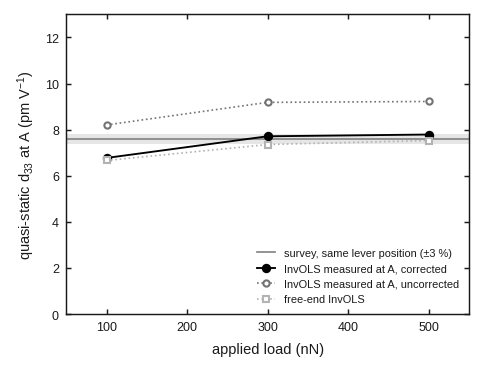

In [3]:
fig, ax = plt.subplots(figsize=(fp.WIDTH_IN["single"], fp.WIDTH_IN["single"] * 0.75))
ax.axhspan(d_stage1_A * 0.97, d_stage1_A * 1.03, color="0.9", lw=0)
ax.axhline(d_stage1_A, color="0.5", lw=0.8, label="survey, same lever position (±3 %)")
ax.plot(lx.load_nN, lx.d33_corr, "ko-", ms=3.5, lw=0.9, label="InvOLS measured at A, corrected")
ax.plot(lx.load_nN, lx.d33_measured_invols, "o:", color="0.45", ms=3, mfc="w", lw=0.8, label="InvOLS measured at A, uncorrected")
ax.plot(lx.load_nN, lx.d33_as_reported, "s:", color="0.7", ms=2.8, mfc="w", lw=0.8, label="free-end InvOLS")
ax.set_xlim(50, 550); ax.set_ylim(0, 13)
ax.set_xlabel("applied load (nN)"); ax.set_ylabel("quasi-static d$_{33}$ at A (pm V$^{-1}$)")
ax.legend(loc="lower right", fontsize=5.3, handlelength=1.6)
fp.save(fig, "SId_load_series_A")